## Figure 1: MAP2/DCX Neurite Analysis and Plotting ##

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

## Step 1: Compile background signal measurements per channel ##

For each channel, background measurements are MGV averaged over ROIs traced within images, and are saved as "BG_" .csv files. BG for EML4, MAP2, and MAP7D1 are analyzed separately, in separate analysis folders to prevent file convolution

In [3]:
import pandas as pd
from pathlib import Path
from tkinter import filedialog
import re

# --------------------------------------------------------
# Select folder containing all CSV files
# --------------------------------------------------------

print("Select folder containing all ROI measurement CSVs")

folder = filedialog.askdirectory(
    title="Select folder containing ROI CSV files"
)

DATA_DIR = Path(folder)

print(f"\nSelected folder:\n{DATA_DIR}\n")

# --------------------------------------------------------
# Parse filenames
# --------------------------------------------------------

def parse_filename(path):

    stem = path.stem

    pattern = (
        r"^(?P<roi_type>BG|GC|Soma)_"
        r"(?P<div>DIV\d+)_"
        r"(?P<fov>FOV\d+)_"
        r"(?P<species>TUBB3|MAP2|DCX)$"
    )

    match = re.match(pattern, stem)

    if match is None:
        print(f"Skipping unrecognized filename: {path.name}")
        return None

    return match.groupdict()

# --------------------------------------------------------
# Read all BG files
# --------------------------------------------------------

bg_records = []

bg_files = sorted(DATA_DIR.glob("BG_*.csv"))

print(f"Found {len(bg_files)} background files.\n")

for file in bg_files:

    info = parse_filename(file)

    if info is None:
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Mean" not in df.columns:
        print(f"Skipping {file.name}: no 'Mean' column found")
        continue

    bg_records.append({
        "DIV": info["div"],
        "FOV": info["fov"],
        "species": info["species"],
        "bg_mean": df["Mean"].mean(),
        "bg_sd": df["Mean"].std(),
        "n_bg_rois": len(df),
        "source_file": file.name
    })

bg_values = pd.DataFrame(bg_records)

bg_values = (
    bg_values
    .sort_values(["DIV", "FOV", "species"])
    .reset_index(drop=True)
)

print("Background summary:")
display(bg_values)

Select folder containing all ROI measurement CSVs

Selected folder:
D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis

Found 20 background files.

Background summary:


,DIV,FOV,species,bg_mean,bg_sd,n_bg_rois,source_file
0,DIV3,FOV1,DCX,139.407889,7.625605,18,BG_DIV3_FOV1_DCX.csv
1,DIV3,FOV1,MAP2,91.256611,1.689457,18,BG_DIV3_FOV1_MAP2.csv
2,DIV3,FOV1,TUBB3,95.369222,3.578959,18,BG_DIV3_FOV1_TUBB3.csv
3,DIV4,FOV1,DCX,149.168381,11.247924,21,BG_DIV4_FOV1_DCX.csv
4,DIV4,FOV1,MAP2,93.275524,2.529531,21,BG_DIV4_FOV1_MAP2.csv
5,DIV4,FOV1,TUBB3,127.644905,6.947913,21,BG_DIV4_FOV1_TUBB3.csv
6,DIV4,FOV2,DCX,141.689793,10.349315,29,BG_DIV4_FOV2_DCX.csv
7,DIV4,FOV2,MAP2,91.878828,3.332088,29,BG_DIV4_FOV2_MAP2.csv
8,DIV4,FOV2,TUBB3,123.803621,6.190248,29,BG_DIV4_FOV2_TUBB3.csv
9,DIV4,FOV3,DCX,138.994650,6.969018,20,BG_DIV4_FOV3_DCX.csv


## Step 2: Compile Max signal measurements per channel ##

Max signal is averaged over ROIs of Soma, where signal is enriched in each channel. Files used for normalization of max signal are "Soma_" .csv files.

In [5]:
# --------------------------------------------------------
# Read all Soma files
# --------------------------------------------------------

soma_records = []

soma_files = sorted(DATA_DIR.glob("Soma_*.csv"))

print(f"Found {len(soma_files)} soma files.\n")

for file in soma_files:

    info = parse_filename(file)

    if info is None:
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Max" not in df.columns:
        print(f"Skipping {file.name}: no 'Max' column found")
        continue

    soma_records.append({
        "DIV": info["div"],
        "FOV": info["fov"],
        "species": info["species"],
        "positive_max": df["Max"].mean(),
        "positive_sd": df["Max"].std(),
        "n_soma_rois": len(df),
        "source_file": file.name
    })

soma_values = pd.DataFrame(soma_records)

soma_values = (
    soma_values
    .sort_values(["DIV", "FOV", "species"])
    .reset_index(drop=True)
)

print("Positive control summary:")
display(soma_values)

Found 20 soma files.

Positive control summary:


,DIV,FOV,species,positive_max,positive_sd,n_soma_rois,source_file
0,DIV3,FOV1,DCX,4698.826087,962.168037,23,Soma_DIV3_FOV1_DCX.csv
1,DIV3,FOV1,MAP2,931.000000,253.856617,23,Soma_DIV3_FOV1_MAP2.csv
2,DIV3,FOV1,TUBB3,2305.782609,402.556598,23,Soma_DIV3_FOV1_TUBB3.csv
3,DIV4,FOV1,DCX,3951.000000,730.176155,24,Soma_DIV4_FOV1_DCX.csv
4,DIV4,FOV1,MAP2,1960.875000,664.891643,24,Soma_DIV4_FOV1_MAP2.csv
5,DIV4,FOV1,TUBB3,2990.583333,632.170788,24,Soma_DIV4_FOV1_TUBB3.csv
6,DIV4,FOV2,DCX,3535.000000,538.887529,27,Soma_DIV4_FOV2_DCX.csv
7,DIV4,FOV2,MAP2,1889.407407,465.743348,27,Soma_DIV4_FOV2_MAP2.csv
8,DIV4,FOV2,TUBB3,2642.518519,436.731952,27,Soma_DIV4_FOV2_TUBB3.csv
9,DIV4,FOV3,DCX,3774.437500,422.232317,16,Soma_DIV4_FOV3_DCX.csv


## Step 3: Compile neurite intensity profiles (lw=3) ##

Neurite profiles are exported from FIJI (ImageJ) as .csv files labeled as "Line_".

In [6]:
import numpy as np
import pandas as pd
import re
from scipy.signal import savgol_filter

# --------------------------------------------------------
# Load all Line_ files automatically
# ImageJ format:
# Distance_(microns), Value, X1, Y1, X2, Y2...
# Intensities are: Value, Y1, Y2, Y3...
# --------------------------------------------------------

line_records = []

line_files = sorted(DATA_DIR.glob("Line_*.csv"))

print(f"Found {len(line_files)} Line files.\n")

for file in line_files:

    parts = file.stem.split("_")

    if len(parts) != 4:
        print(f"Skipping {file.name}: unrecognized filename")
        continue

    roi_type, div, fov, species = parts

    if roi_type != "Line":
        continue

    df = pd.read_csv(file, encoding="utf-8")
    df.columns = df.columns.str.strip()

    if "Distance_(microns)" not in df.columns:
        print(f"Skipping {file.name}: no Distance_(microns) column")
        continue

    distance_col = "Distance_(microns)"

    intensity_cols = ["Value"] + [
        col for col in df.columns
        if re.match(r"^Y\d+$", col)
    ]

    print(f"{file.name}: found {len(intensity_cols)} ROI profiles")

    for roi_num, intensity_col in enumerate(intensity_cols, start=1):

        for i, row in df.iterrows():

            line_records.append({
                "DIV": div,
                "FOV": fov,
                "species": species,
                "channel": species,
                "roi_id": f"ROI_{roi_num}",
                "distance_um": row[distance_col],
                "intensity_raw": row[intensity_col],
                "source_file": file.name,
                "source_column": intensity_col
            })

lineplots_auto = pd.DataFrame(line_records)

print("Loaded line profiles:")
display(lineplots_auto.head())

print("\nROI counts per DIV/FOV/species:")
display(
    lineplots_auto
    .groupby(["DIV", "FOV", "species"])["roi_id"]
    .nunique()
    .reset_index(name="n_rois")
)


# --------------------------------------------------------
# Make BG and Soma lookup tables
# --------------------------------------------------------

bg_lookup = (
    bg_values
    .set_index(["DIV", "FOV", "species"])["bg_mean"]
    .to_dict()
)

soma_lookup = (
    soma_values
    .set_index(["DIV", "FOV", "species"])["positive_max"]
    .to_dict()
)


# --------------------------------------------------------
# Helper functions
# --------------------------------------------------------

def minmax_norm(y):
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    y = y.replace([np.inf, -np.inf], np.nan)
    y = y.interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(y) == 0 or np.all(np.isnan(y)):
        return y

    if np.nanmax(y) == np.nanmin(y):
        return np.zeros_like(y)

    return (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))


def safe_smooth(y, window=9, poly=2):
    y = pd.to_numeric(pd.Series(y), errors="coerce")
    y = y.replace([np.inf, -np.inf], np.nan)
    y = y.interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(y) < 5:
        return y

    if np.all(np.isnan(y)):
        return y

    if window % 2 == 0:
        window += 1

    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if window <= poly:
        return y

    try:
        return savgol_filter(
            y,
            window_length=window,
            polyorder=poly,
            mode="nearest"
        )
    except Exception as e:
        print(f"Smoothing skipped: {e}")
        return y


# --------------------------------------------------------
# Process line profiles
# --------------------------------------------------------

processed_records = []

for (div, fov, species, roi_id), g in lineplots_auto.groupby(
    ["DIV", "FOV", "species", "roi_id"]
):

    key = (div, fov, species)

    if key not in bg_lookup:
        print(f"Skipping {div} {fov} {species} {roi_id}: no matching BG")
        continue

    if key not in soma_lookup:
        print(f"Skipping {div} {fov} {species} {roi_id}: no matching Soma")
        continue

    g = g.copy()

    g["distance_um"] = pd.to_numeric(g["distance_um"], errors="coerce")
    g["intensity_raw"] = pd.to_numeric(g["intensity_raw"], errors="coerce")

    g = g.dropna(subset=["distance_um", "intensity_raw"])
    g = g.sort_values("distance_um")

    if len(g) < 2:
        print(f"Skipping {div} {fov} {species} {roi_id}: not enough points")
        continue

    x = g["distance_um"].to_numpy(dtype=float)
    y = g["intensity_raw"].to_numpy(dtype=float)

    if np.nanmax(x) == np.nanmin(x):
        print(f"Skipping {div} {fov} {species} {roi_id}: distance range is zero")
        continue

    bg = bg_lookup[key]
    soma_max = soma_lookup[key]
    denom = soma_max - bg

    distance_norm = (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

    intensity_bgsub = y - bg

    if denom == 0:
        intensity_norm_soma_max = np.full_like(y, np.nan, dtype=float)
    else:
        intensity_norm_soma_max = (y - bg) / denom

    intensity_bgsub_smooth = safe_smooth(intensity_bgsub)
    intensity_norm_soma_max_smooth = safe_smooth(intensity_norm_soma_max)
    intensity_profile_minmax = minmax_norm(intensity_bgsub_smooth)

    for i in range(len(x)):

        processed_records.append({
            "DIV": div,
            "FOV": fov,
            "species": species,
            "channel": species,
            "roi_id": roi_id,
            "source_file": g["source_file"].iloc[0],
            "source_column": g["source_column"].iloc[0],

            "distance_um": x[i],
            "distance_norm": distance_norm[i],

            "intensity_raw": y[i],
            "background_value": bg,
            "soma_max_value": soma_max,

            "intensity_bgsub": intensity_bgsub[i],
            "intensity_bgsub_smooth": intensity_bgsub_smooth[i],

            "intensity_norm_soma_max": intensity_norm_soma_max[i],
            "intensity_norm_soma_max_smooth": intensity_norm_soma_max_smooth[i],

            "intensity_profile_minmax": intensity_profile_minmax[i]
        })

processed_df = pd.DataFrame(processed_records)

processed_df = (
    processed_df
    .sort_values(["DIV", "FOV", "roi_id", "species", "distance_um"])
    .reset_index(drop=True)
)

display(processed_df.head())

print("\nProcessed ROI counts per DIV/FOV:")
display(
    processed_df
    .groupby(["DIV", "FOV"])["roi_id"]
    .nunique()
    .reset_index(name="n_rois")
)

Found 20 Line files.

Line_DIV3_FOV1_DCX.csv: found 42 ROI profiles
Line_DIV3_FOV1_MAP2.csv: found 42 ROI profiles
Line_DIV3_FOV1_TUBB3.csv: found 42 ROI profiles
Line_DIV4_FOV1_DCX.csv: found 20 ROI profiles
Line_DIV4_FOV1_MAP2.csv: found 20 ROI profiles
Line_DIV4_FOV1_TUBB3.csv: found 20 ROI profiles
Line_DIV4_FOV2_DCX.csv: found 21 ROI profiles
Line_DIV4_FOV2_MAP2.csv: found 21 ROI profiles
Line_DIV4_FOV2_TUBB3.csv: found 21 ROI profiles
Line_DIV4_FOV3_DCX.csv: found 13 ROI profiles
Line_DIV4_FOV3_MAP2.csv: found 13 ROI profiles
Line_DIV4_FOV3_TUBB3.csv: found 13 ROI profiles
Line_DIV5_FOV1_MAP2.csv: found 19 ROI profiles
Line_DIV5_FOV1_TUBB3.csv: found 19 ROI profiles
Line_DIV5_FOV2_DCX.csv: found 17 ROI profiles
Line_DIV5_FOV2_TUBB3.csv: found 17 ROI profiles
Line_DIV5_FOV3_MAP2.csv: found 24 ROI profiles
Line_DIV5_FOV3_TUBB3.csv: found 24 ROI profiles
Line_DIV5_FOV4_MAP2.csv: found 12 ROI profiles
Line_DIV5_FOV4_TUBB3.csv: found 12 ROI profiles
Loaded line profiles:


,DIV,FOV,species,channel,roi_id,distance_um,intensity_raw,source_file,source_column
0,DIV3,FOV1,DCX,DCX,ROI_1,0.000,1267.000,Line_DIV3_FOV1_DCX.csv,Value
1,DIV3,FOV1,DCX,DCX,ROI_1,0.227,1009.157,Line_DIV3_FOV1_DCX.csv,Value
2,DIV3,FOV1,DCX,DCX,ROI_1,0.454,813.107,Line_DIV3_FOV1_DCX.csv,Value
3,DIV3,FOV1,DCX,DCX,ROI_1,0.681,628.678,Line_DIV3_FOV1_DCX.csv,Value
4,DIV3,FOV1,DCX,DCX,ROI_1,0.908,546.949,Line_DIV3_FOV1_DCX.csv,Value



ROI counts per DIV/FOV/species:


,DIV,FOV,species,n_rois
0,DIV3,FOV1,DCX,42
1,DIV3,FOV1,MAP2,42
2,DIV3,FOV1,TUBB3,42
3,DIV4,FOV1,DCX,20
4,DIV4,FOV1,MAP2,20
5,DIV4,FOV1,TUBB3,20
6,DIV4,FOV2,DCX,21
7,DIV4,FOV2,MAP2,21
8,DIV4,FOV2,TUBB3,21
9,DIV4,FOV3,DCX,13


Skipping DIV5 FOV2 DCX ROI_1: no matching BG
Skipping DIV5 FOV2 DCX ROI_10: no matching BG
Skipping DIV5 FOV2 DCX ROI_11: no matching BG
Skipping DIV5 FOV2 DCX ROI_12: no matching BG
Skipping DIV5 FOV2 DCX ROI_13: no matching BG
Skipping DIV5 FOV2 DCX ROI_14: no matching BG
Skipping DIV5 FOV2 DCX ROI_15: no matching BG
Skipping DIV5 FOV2 DCX ROI_16: no matching BG
Skipping DIV5 FOV2 DCX ROI_17: no matching BG
Skipping DIV5 FOV2 DCX ROI_2: no matching BG
Skipping DIV5 FOV2 DCX ROI_3: no matching BG
Skipping DIV5 FOV2 DCX ROI_4: no matching BG
Skipping DIV5 FOV2 DCX ROI_5: no matching BG
Skipping DIV5 FOV2 DCX ROI_6: no matching BG
Skipping DIV5 FOV2 DCX ROI_7: no matching BG
Skipping DIV5 FOV2 DCX ROI_8: no matching BG
Skipping DIV5 FOV2 DCX ROI_9: no matching BG


,DIV,FOV,species,channel,roi_id,source_file,source_column,distance_um,distance_norm,intensity_raw,background_value,soma_max_value,intensity_bgsub,intensity_bgsub_smooth,intensity_norm_soma_max,intensity_norm_soma_max_smooth,intensity_profile_minmax
0,DIV3,FOV1,DCX,DCX,ROI_1,Line_DIV3_FOV1_DCX.csv,Value,0.000,0.000000,1267.000,139.407889,4698.826087,1127.592111,1017.458838,0.247311,0.223155,0.581429
1,DIV3,FOV1,DCX,DCX,ROI_1,Line_DIV3_FOV1_DCX.csv,Value,0.227,0.001054,1009.157,139.407889,4698.826087,869.749111,874.955146,0.190759,0.191901,0.491402
2,DIV3,FOV1,DCX,DCX,ROI_1,Line_DIV3_FOV1_DCX.csv,Value,0.454,0.002107,813.107,139.407889,4698.826087,673.699111,704.654258,0.147760,0.154549,0.383815
3,DIV3,FOV1,DCX,DCX,ROI_1,Line_DIV3_FOV1_DCX.csv,Value,0.681,0.003161,628.678,139.407889,4698.826087,489.270111,537.362020,0.107310,0.117858,0.278128
4,DIV3,FOV1,DCX,DCX,ROI_1,Line_DIV3_FOV1_DCX.csv,Value,0.908,0.004215,546.949,139.407889,4698.826087,407.541111,408.649466,0.089384,0.089628,0.196814



Processed ROI counts per DIV/FOV:


,DIV,FOV,n_rois
0,DIV3,FOV1,42
1,DIV4,FOV1,20
2,DIV4,FOV2,21
3,DIV4,FOV3,13
4,DIV5,FOV1,19
5,DIV5,FOV2,17
6,DIV5,FOV3,24
7,DIV5,FOV4,12


## Step 4: Plot profiles corrected for channel-specific BG and MAX signal ##

Script normalizes neurite profile x values according to background signal and average maximum signal. Neurites are also normalized to length = 1.0.

In [11]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --------------------------------------------------------
# Output folder
# --------------------------------------------------------

LINE_OUT_DIR = DATA_DIR / "Processed_LineProfiles"
LINE_OUT_DIR.mkdir(exist_ok=True)

processed_df.to_csv(
    LINE_OUT_DIR / "all_processed_lineprofiles.csv",
    index=False
)

print(f"Saved processed_df to:\n{LINE_OUT_DIR / 'all_processed_lineprofiles.csv'}")

# --------------------------------------------------------
# Colors
# --------------------------------------------------------

colors = {
    "TUBB3": "#00BCD4",
    "DCX": "#555555",
    # "EML4": "#F48FB1"
    # "MAP7D1": "#C2185B",
    "MAP2": "#C2185B"
}

# --------------------------------------------------------
# ROI sorting helper
# --------------------------------------------------------

def natural_sort_key(x):
    return [
        int(text) if text.isdigit() else text.lower()
        for text in re.split(r"(\d+)", str(x))
    ]

# --------------------------------------------------------
# Plot first N line-profile ROIs from selected DIV/FOV
# --------------------------------------------------------

def plot_lineprofiles_by_div_fov(
    processed_df,
    div,
    fov,
    n_rois=5,
    y_col="intensity_norm_soma_max_smooth",
    x_col="distance_norm",
    save=True
):

    subset = processed_df[
        (processed_df["DIV"] == div) &
        (processed_df["FOV"] == fov)
    ].copy()

    if subset.empty:
        print(f"No data found for {div} {fov}")
        return

    roi_ids = sorted(
        subset["roi_id"].dropna().unique(),
        key=natural_sort_key
    )[:n_rois]

    print(f"Plotting first {len(roi_ids)} ROI(s) for {div} {fov}:")
    print(roi_ids)

    for roi_id in roi_ids:

        g_roi = subset[subset["roi_id"] == roi_id].copy()

        plt.figure(figsize=(5, 4))

        for species in ["TUBB3","MAP2","DCX"]:

            g = g_roi[g_roi["species"] == species].copy()

            if g.empty:
                continue

            g = g.sort_values(x_col)

            plt.plot(
                g[x_col],
                g[y_col],
                linewidth=2,
                color=colors[species],
                label=species
            )

        plt.title(f"{div} {fov} • {roi_id}")
        plt.xlabel("Normalized distance")
        plt.ylabel("Normalized intensity")
        plt.xlim(0, 1)
        plt.ylim(0,0.8)
        plt.legend(frameon=False)
        plt.tight_layout()

        if save:
            filename = f"{div}_{fov}_{roi_id}_{y_col}.png"
            save_path = LINE_OUT_DIR / filename
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")
            
            filename = f"{div}_{fov}_{roi_id}_{y_col}.svg"
            save_path = LINE_OUT_DIR / filename
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")

        plt.show()

Saved processed_df to:
D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\all_processed_lineprofiles.csv


Plotting first 3 ROI(s) for DIV4 FOV1:
['ROI_1', 'ROI_2', 'ROI_3']
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\DIV4_FOV1_ROI_1_intensity_norm_soma_max_smooth.png
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\DIV4_FOV1_ROI_1_intensity_norm_soma_max_smooth.svg


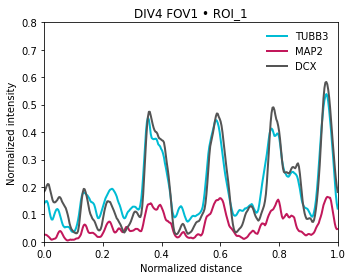

Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\DIV4_FOV1_ROI_2_intensity_norm_soma_max_smooth.png
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\DIV4_FOV1_ROI_2_intensity_norm_soma_max_smooth.svg


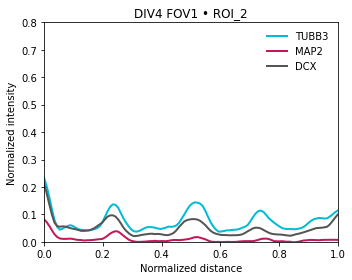

Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\DIV4_FOV1_ROI_3_intensity_norm_soma_max_smooth.png
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\DIV4_FOV1_ROI_3_intensity_norm_soma_max_smooth.svg


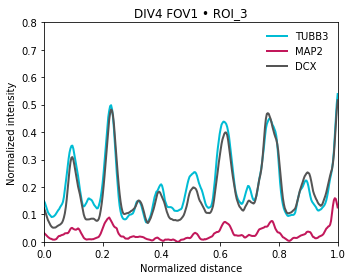

In [15]:
#Select profiles to plot from available DIVs (div) and FOVs (fov), and select number of ROIs to plot and save (n_rois)

plot_lineprofiles_by_div_fov(
    processed_df,
    div="DIV4",
    fov="FOV1",
    n_rois=3
)

## Step 5: Calculate signal intensity ratio of MAP2:TUBB3 and DCX:TUBB3 ##

Script calculates median intensity value per neurite/process and plots mean of medians per FOV and DIV.

Skipping DIV5, FOV2, ROI_1: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_10: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_11: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_12: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_13: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_14: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_15: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_16: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_17: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_2: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_3: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_4: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_5: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_6: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_7: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_8: missing MAP2 or TUBB3
Skipping DIV5, FOV2, ROI_9: missing MAP2 or TUBB3
Skipping DIV5, FOV1, ROI_1: missing DCX or TUBB3
Skipping DIV5, FOV1, ROI_10: missing DCX or TUBB3
Skipping DIV5, FOV1, ROI_11: missing DCX or

,DIV,FOV,roi_id,ratio_mean,ratio_median,ratio_auc,n_valid_positions,numerator_species,denominator_species
0,DIV3,FOV1,ROI_1,0.893599,0.730452,0.889792,200,MAP2,TUBB3
1,DIV3,FOV1,ROI_10,1.199065,1.084492,1.217556,197,MAP2,TUBB3
2,DIV3,FOV1,ROI_11,1.225031,1.152363,1.224513,200,MAP2,TUBB3
3,DIV3,FOV1,ROI_12,1.164118,1.099076,1.159881,200,MAP2,TUBB3
4,DIV3,FOV1,ROI_13,2.231881,2.068006,2.235886,200,MAP2,TUBB3



FOV-level ratio summary:


,numerator_species,denominator_species,DIV,FOV,ratio_mean,ratio_sem,n_processes
0,DCX,TUBB3,DIV3,FOV1,0.884128,0.023659,42
1,DCX,TUBB3,DIV4,FOV1,0.783740,0.041935,20
2,DCX,TUBB3,DIV4,FOV2,0.858501,0.031020,21
3,DCX,TUBB3,DIV4,FOV3,0.843359,0.036230,13
4,MAP2,TUBB3,DIV3,FOV1,1.087416,0.067123,42
5,MAP2,TUBB3,DIV4,FOV1,0.283115,0.037795,20
6,MAP2,TUBB3,DIV4,FOV2,0.222141,0.029722,21
7,MAP2,TUBB3,DIV4,FOV3,0.277407,0.029732,13
8,MAP2,TUBB3,DIV5,FOV1,0.185388,0.025057,19
9,MAP2,TUBB3,DIV5,FOV3,0.243641,0.024428,24



Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\MAP7D1_DCX_TUBB3_ratio\MAP2_DCX_TUBB3_pointwise_ratio_profiles.csv
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\MAP7D1_DCX_TUBB3_ratio\MAP2_DCX_TUBB3_ratio_per_process.csv
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\MAP7D1_DCX_TUBB3_ratio\MAP2_DCX_TUBB3_ratio_per_FOV.csv
No DCX:TUBB3 ratio profiles found for DIV5
Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\MAP7D1_DCX_TUBB3_ratio\MAP2_DCX-TUBB3_ratio_profiles_by_DIV.svg


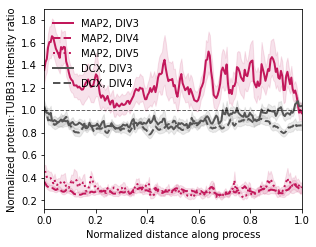

C:\Users\Brandi\anaconda3\lib\site-packages\matplotlib\axes\_base.py:2141: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\MAP7D1_DCX_TUBB3_ratio\MA2_DCX_TUBB3_median_ratio_by_DIV.svg


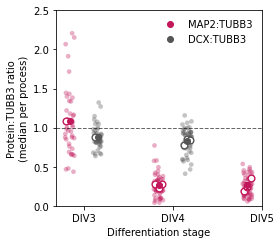

Saved: D:\Manuscripts\Proximity Labeling\Microscopy\Widefield - Analysis\MAP2 analysis\Processed_LineProfiles\MAP7D1_DCX_TUBB3_ratio\MAP2_DCX_TUBB3_ratio_FOV_means_by_DIV.svg


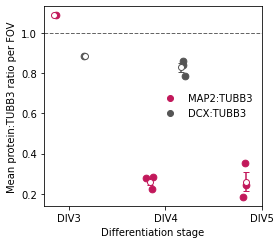

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIGURATION
# ============================================================

Y_COL = "intensity_norm_soma_max_smooth"
X_COL = "distance_norm"

NUMERATOR_SPECIES = ["MAP2", "DCX"]
DENOMINATOR_SPECIES = "TUBB3"

DIV_ORDER = ["DIV3", "DIV4", "DIV5"]

COMMON_X = np.linspace(0, 1, 200)

# Exclude points where normalized TUBB3 is extremely close to zero.
DENOMINATOR_FLOOR = 0.02

# Summary statistic used to generate one ratio per process.
PROCESS_SUMMARY_METHOD = "median"   # "median", "mean", or "auc"

# Output directory
try:
    RATIO_OUT_DIR = Path(LINE_OUT_DIR) / "MAP7D1_DCX_TUBB3_ratio"
except NameError:
    RATIO_OUT_DIR = Path("MAP7D1_DCX_TUBB3_ratio")

RATIO_OUT_DIR.mkdir(parents=True, exist_ok=True)

DCX_COLOR = "#555555"
MAP2_COLOR = "#C2185B"
#EML4_COLOR = "#F48FB1"

SPECIES_COLORS = {
    "MAP2": MAP7D1_COLOR,
    "DCX": DCX_COLOR
}

SPECIES_OFFSETS = {
    "MAP2": -0.16,
    "DCX": 0.16
}

DIV_LINESTYLES = {
    "DIV3": "-",
    "DIV4": "--",
    "DIV5": ":"
}

# ============================================================
# HELPER: INTERPOLATE ONE SPECIES PROFILE
# ============================================================

def interpolate_species_profile(
    group,
    common_x,
    x_col,
    y_col
):
    """
    Interpolate one species profile onto a common normalized-distance axis.
    """

    group = (
        group[[x_col, y_col]]
        .dropna()
        .sort_values(x_col)
        .copy()
    )

    if len(group) < 2:
        return None

    # Collapse duplicate x values before interpolation.
    group = (
        group.groupby(x_col, as_index=False)[y_col]
        .mean()
        .sort_values(x_col)
    )

    if len(group) < 2:
        return None

    x = group[x_col].to_numpy(dtype=float)
    y = group[y_col].to_numpy(dtype=float)

    interpolated = np.interp(
        common_x,
        x,
        y,
        left=np.nan,
        right=np.nan
    )

    return interpolated


# ============================================================
# BUILD POINT-BY-POINT DCX:TUBB3 RATIO PROFILES
# ============================================================

def _calculate_single_process_ratio_profiles(
    processed_df,
    numerator_species=NUMERATOR_SPECIES,
    denominator_species=DENOMINATOR_SPECIES,
    y_col=Y_COL,
    x_col=X_COL,
    common_x=COMMON_X,
    denominator_floor=DENOMINATOR_FLOOR
):
    """
    Pair MAP2/MAP7D1/EML4, DCX and TUBB3 profiles within each DIV/FOV/roi_id and calculate
    the point-by-point DCX:TUBB3 ratio.

    Returns
    -------
    ratio_long_df:
        One row per interpolated distance point per process.

    process_summary_df:
        One summary ratio per process.
    """

    required_columns = {
        "DIV",
        "FOV",
        "roi_id",
        "species",
        x_col,
        y_col
    }

    missing = required_columns.difference(processed_df.columns)

    if missing:
        raise KeyError(
            "The following required columns are missing:\n"
            + "\n".join(sorted(missing))
        )

    df = processed_df[
        processed_df["species"].isin(
            [numerator_species, denominator_species]
        )
    ].copy()

    ratio_records = []
    summary_records = []

    grouping_columns = ["DIV", "FOV", "roi_id"]

    for group_keys, group in df.groupby(grouping_columns):

        div, fov, roi_id = group_keys

        numerator_group = group[
            group["species"] == numerator_species
        ]

        denominator_group = group[
            group["species"] == denominator_species
        ]

        if numerator_group.empty or denominator_group.empty:
            print(
                f"Skipping {div}, {fov}, {roi_id}: "
                f"missing {numerator_species} or {denominator_species}"
            )
            continue

        numerator_interp = interpolate_species_profile(
            numerator_group,
            common_x,
            x_col,
            y_col
        )

        denominator_interp = interpolate_species_profile(
            denominator_group,
            common_x,
            x_col,
            y_col
        )

        if numerator_interp is None or denominator_interp is None:
            continue

        valid = (
            np.isfinite(numerator_interp)
            & np.isfinite(denominator_interp)
            & (denominator_interp >= denominator_floor)
        )

        ratio = np.full(common_x.shape, np.nan, dtype=float)

        ratio[valid] = (
            numerator_interp[valid]
            / denominator_interp[valid]
        )

        number_valid = np.sum(np.isfinite(ratio))

        if number_valid < 2:
            print(
                f"Skipping {div}, {fov}, {roi_id}: "
                "too few valid ratio positions"
            )
            continue

        for distance, numerator_value, denominator_value, ratio_value in zip(
            common_x,
            numerator_interp,
            denominator_interp,
            ratio
        ):
            ratio_records.append(
                {
                    "DIV": div,
                    "FOV": fov,
                    "roi_id": roi_id,
                    "distance_norm": distance,
                    f"{numerator_species}_intensity": numerator_value,
                    f"{denominator_species}_intensity": denominator_value,
                    "ratio": ratio_value
                }
            )

        valid_ratio = ratio[np.isfinite(ratio)]
        valid_x = common_x[np.isfinite(ratio)]

        process_mean = np.nanmean(valid_ratio)
        process_median = np.nanmedian(valid_ratio)

        if len(valid_x) >= 2 and valid_x[-1] > valid_x[0]:
            process_auc = (
                np.trapz(valid_ratio, valid_x)
                / (valid_x[-1] - valid_x[0])
            )
        else:
            process_auc = np.nan

        summary_records.append(
            {
                "DIV": div,
                "FOV": fov,
                "roi_id": roi_id,
                "ratio_mean": process_mean,
                "ratio_median": process_median,
                "ratio_auc": process_auc,
                "n_valid_positions": number_valid
            }
        )

    ratio_long_df = pd.DataFrame(ratio_records)
    process_summary_df = pd.DataFrame(summary_records)

    if ratio_long_df.empty:
        raise ValueError(
            "No paired ratio profiles were generated. "
        )

    return ratio_long_df, process_summary_df


# ============================================================
# CALCULATE MULTIPLE NUMERATOR:TUBB3 RATIOS REPRODUCIBLY
# ============================================================

def calculate_process_ratio_profiles(
    processed_df,
    numerator_species=NUMERATOR_SPECIES,
    denominator_species=DENOMINATOR_SPECIES,
    y_col=Y_COL,
    x_col=X_COL,
    common_x=COMMON_X,
    denominator_floor=DENOMINATOR_FLOOR
):
    """
    Calculate each requested numerator:denominator ratio independently, then
    combine the results while retaining the numerator identity in every row.
    """

    if isinstance(numerator_species, str):
        numerator_species = [numerator_species]

    long_frames = []
    summary_frames = []

    for species_name in numerator_species:
        species_long, species_summary = (
            _calculate_single_process_ratio_profiles(
                processed_df=processed_df,
                numerator_species=species_name,
                denominator_species=denominator_species,
                y_col=y_col,
                x_col=x_col,
                common_x=common_x,
                denominator_floor=denominator_floor
            )
        )

        species_long = species_long.rename(
            columns={
                f"{species_name}_intensity": "numerator_intensity",
                f"{denominator_species}_intensity": "denominator_intensity"
            }
        )
        species_long["numerator_species"] = species_name
        species_long["denominator_species"] = denominator_species

        species_summary["numerator_species"] = species_name
        species_summary["denominator_species"] = denominator_species

        long_frames.append(species_long)
        summary_frames.append(species_summary)

    if not long_frames:
        raise ValueError("No ratio profiles were generated for any numerator.")

    return (
        pd.concat(long_frames, ignore_index=True),
        pd.concat(summary_frames, ignore_index=True)
    )


# ============================================================
# CALCULATE RATIOS
# ============================================================

ratio_long_df, process_ratio_df = (
    calculate_process_ratio_profiles(
        processed_df=processed_df
    )
)

print(
    f"Generated MAP2:TUBB3 and DCX:TUBB3 ratio profiles for "
    f"{len(process_ratio_df)} species/DIV/FOV/ROI combinations."
)

display(process_ratio_df.head())


# ============================================================
# CHOOSE PROCESS-LEVEL SUMMARY COLUMN
# ============================================================

summary_column_lookup = {
    "mean": "ratio_mean",
    "median": "ratio_median",
    "auc": "ratio_auc"
}

if PROCESS_SUMMARY_METHOD not in summary_column_lookup:
    raise ValueError(
        "PROCESS_SUMMARY_METHOD must be 'mean', 'median', or 'auc'."
    )

PROCESS_RATIO_COL = summary_column_lookup[PROCESS_SUMMARY_METHOD]


# ============================================================
# CALCULATE ONE MEAN PER FOV
# ============================================================

fov_ratio_df = (
    process_ratio_df
    .groupby(["numerator_species", "denominator_species", "DIV", "FOV"], as_index=False)
    .agg(
        ratio_mean=(PROCESS_RATIO_COL, "mean"),
        ratio_sem=(
            PROCESS_RATIO_COL,
            lambda x: (
                np.nanstd(x, ddof=1) / np.sqrt(np.sum(np.isfinite(x)))
                if np.sum(np.isfinite(x)) > 1
                else np.nan
            )
        ),
        n_processes=(PROCESS_RATIO_COL, "count")
    )
)

print("\nFOV-level ratio summary:")
display(fov_ratio_df)


# ============================================================
# EXPORT DATA
# ============================================================

ratio_long_path = (
    RATIO_OUT_DIR
    / "MAP2_DCX_TUBB3_pointwise_ratio_profiles.csv"
)

process_ratio_path = (
    RATIO_OUT_DIR
    / "MAP2_DCX_TUBB3_ratio_per_process.csv"
)

fov_ratio_path = (
    RATIO_OUT_DIR
    / "MAP2_DCX_TUBB3_ratio_per_FOV.csv"
)

ratio_long_df.to_csv(ratio_long_path, index=False)
process_ratio_df.to_csv(process_ratio_path, index=False)
fov_ratio_df.to_csv(fov_ratio_path, index=False)

print(f"\nSaved: {ratio_long_path}")
print(f"Saved: {process_ratio_path}")
print(f"Saved: {fov_ratio_path}")


# ============================================================
# PLOT 1:
# MEAN DCX:TUBB3 RATIO ALONG THE PROCESS FOR EACH DIV
# ============================================================

plt.figure(figsize=(4.5, 3.5))

for species_name in NUMERATOR_SPECIES:
    for div in DIV_ORDER:

        div_data = ratio_long_df[
            (ratio_long_df["DIV"] == div)
            & (ratio_long_df["numerator_species"] == species_name)
        ].copy()

        if div_data.empty:
            print(f"No {species_name}:TUBB3 ratio profiles found for {div}")
            continue

        process_profiles = (
            div_data
            .pivot_table(
                index=["FOV", "roi_id"],
                columns="distance_norm",
                values="ratio",
                aggfunc="mean"
            )
        )

        profile_array = process_profiles.to_numpy(dtype=float)
        profile_x = process_profiles.columns.to_numpy(dtype=float)

        n_at_position = np.sum(np.isfinite(profile_array), axis=0)

        mean_profile = np.nanmean(profile_array, axis=0)

        sem_profile = np.divide(
            np.nanstd(profile_array, axis=0, ddof=1),
            np.sqrt(n_at_position),
            out=np.full(mean_profile.shape, np.nan),
            where=n_at_position > 1
        )

        plt.plot(
            profile_x,
            mean_profile,
            linewidth=2,
            color=SPECIES_COLORS[species_name],
            linestyle=DIV_LINESTYLES.get(div, "-"),
            label=f"{species_name}, {div}"
        )

        plt.fill_between(
            profile_x,
            mean_profile - sem_profile,
            mean_profile + sem_profile,
            color=SPECIES_COLORS[species_name],
            alpha=0.12
        )

plt.axhline(
    1,
    linestyle="--",
    linewidth=1,
    color="black",
    alpha=0.6
)

plt.xlabel("Normalized distance along process")
plt.ylabel("Normalized protein:TUBB3 intensity ratio")
plt.xlim(0, 1)
plt.legend(frameon=False)
plt.tight_layout()

ratio_profile_plot_path = (
    RATIO_OUT_DIR
    / "MAP2_DCX-TUBB3_ratio_profiles_by_DIV.svg"
)

plt.savefig(
    ratio_profile_plot_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {ratio_profile_plot_path}")

plt.show()


# ============================================================
# PLOT 2:
# ONE VALUE PER PROCESS, WITH FOV MEANS OVERLAID
# ============================================================

fig, ax = plt.subplots(figsize=(4, 3.5))

x_positions = np.arange(len(DIV_ORDER))

rng = np.random.default_rng(42)

for x_position, div in zip(x_positions, DIV_ORDER):
    for species_name in NUMERATOR_SPECIES:
        species_offset = SPECIES_OFFSETS[species_name]
        species_color = SPECIES_COLORS[species_name]

        process_values = (
            process_ratio_df.loc[
                (process_ratio_df["DIV"] == div)
                & (process_ratio_df["numerator_species"] == species_name),
                PROCESS_RATIO_COL
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        if len(process_values) == 0:
            continue

        jitter = rng.uniform(-0.055, 0.055, size=len(process_values))

        # Individual traced processes, dodged by numerator species.
        ax.scatter(
            np.full(len(process_values), x_position + species_offset) + jitter,
            process_values,
            s=22,
            alpha=0.35,
            color=species_color,
            edgecolors="none",
            zorder=1
        )

        div_fovs = fov_ratio_df[
            (fov_ratio_df["DIV"] == div)
            & (fov_ratio_df["numerator_species"] == species_name)
        ].copy()

        if not div_fovs.empty:
            fov_jitter = np.linspace(-0.035, 0.035, len(div_fovs))

            # Individual FOV means.
            ax.scatter(
                np.full(len(div_fovs), x_position + species_offset) + fov_jitter,
                div_fovs["ratio_mean"],
                s=45,
                facecolors="white",
                edgecolors=species_color,
                linewidths=1.4,
                zorder=3
            )

            grand_mean = div_fovs["ratio_mean"].mean()
            grand_sem = (
                div_fovs["ratio_mean"].std(ddof=1) / np.sqrt(len(div_fovs))
                if len(div_fovs) > 1 else np.nan
            )

            ax.errorbar(
                x_position + species_offset,
                grand_mean,
                yerr=grand_sem,
                fmt="o",
                markersize=6,
                color=species_color,
                capsize=3,
                linewidth=1.5,
                zorder=4
            )

ax.axhline(
    1,
    linestyle="--",
    linewidth=1,
    color="black",
    alpha=0.6
)

ax.set_xticks(x_positions)
ax.set_xticklabels(DIV_ORDER)

ax.set_xlabel("Differentiation stage")
ax.set_ylim(0, 2.5)
ax.set_ylabel(
    f"Protein:TUBB3 ratio\n"
    f"({PROCESS_SUMMARY_METHOD} per process)"
)

legend_handles = [
    plt.Line2D(
        [0], [0], marker="o", linestyle="none",
        markerfacecolor=SPECIES_COLORS[name],
        markeredgecolor=SPECIES_COLORS[name],
        label=f"{name}:TUBB3"
    )
    for name in NUMERATOR_SPECIES
]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()

process_plot_path = (
    RATIO_OUT_DIR
    / f"MA2_DCX_TUBB3_{PROCESS_SUMMARY_METHOD}_ratio_by_DIV.svg"
)

plt.savefig(
    process_plot_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {process_plot_path}")

plt.show()


# ============================================================
# PLOT 3:
# FOV-LEVEL VALUES ONLY
# ============================================================

fig, ax = plt.subplots(figsize=(4, 3.5))

rng = np.random.default_rng(42)

for x_position, div in zip(x_positions, DIV_ORDER):
    for species_name in NUMERATOR_SPECIES:
        species_offset = SPECIES_OFFSETS[species_name]
        species_color = SPECIES_COLORS[species_name]

        values = (
            fov_ratio_df.loc[
                (fov_ratio_df["DIV"] == div)
                & (fov_ratio_df["numerator_species"] == species_name),
                "ratio_mean"
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        if len(values) == 0:
            continue

        jitter = rng.uniform(-0.045, 0.045, size=len(values))

        ax.scatter(
            np.full(len(values), x_position + species_offset) + jitter,
            values,
            s=45,
            color=species_color,
            zorder=2
        )

        group_mean = np.mean(values)
        group_sem = (
            np.std(values, ddof=1) / np.sqrt(len(values))
            if len(values) > 1 else np.nan
        )

        ax.errorbar(
            x_position + species_offset,
            group_mean,
            yerr=group_sem,
            fmt="o",
            markersize=6,
            markerfacecolor="white",
            color=species_color,
            capsize=3,
            linewidth=1.5,
            zorder=3
        )

ax.axhline(
    1,
    linestyle="--",
    linewidth=1,
    color="black",
    alpha=0.6
)

ax.set_xticks(x_positions)
ax.set_xticklabels(DIV_ORDER)

ax.set_xlabel("Differentiation stage")
ax.set_ylabel("Mean protein:TUBB3 ratio per FOV")
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()

fov_plot_path = (
    RATIO_OUT_DIR
    / "MAP2_DCX_TUBB3_ratio_FOV_means_by_DIV.svg"
)

plt.savefig(
    fov_plot_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {fov_plot_path}")

plt.show()
